In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
from tweezepy import allanvar as tpy
import scipy

In [2]:
def process_data(data_txt):
    # Read data
    cols = ['MJD','R.A. (mas)', 'Dec. (mas)', 'Err. R.A. (mas)', 'Err. Dec. (mas)', 'Corr.', 'Del.']
    cols_widths = [(0,9),(9,26),(27,46),(47,56),(57,66),(67,74),(75,79)]
    df = pd.read_fwf(data_txt, colspecs=cols_widths, skiprows=4, header=None, names=cols) 
    
    # Convert to float
    df_new = df.apply(pd.to_numeric, errors='coerce').dropna()    
    
    # Convert from mas to microas
    df_new['R.A. (micas)'] = df_new['R.A. (mas)']*1000
    df_new['Dec. (micas)'] = df_new['Dec. (mas)']*1000
    df_new['Err. R.A. (micas)'] = df_new['Err. R.A. (mas)']*1000
    df_new['Err. Dec. (micas)'] = df_new['Err. Dec. (mas)']*1000
    
    # Convert from mas to degrees to radian
    df_new['Dec. (rad)'] = (df_new['Dec. (micas)']/(3600*1000)).apply(np.deg2rad)
    
    # Calculate RA*cos(dec) column
    
    df_new['RAcosDEC'] = df_new['R.A. (micas)']*np.cos(df_new['Dec. (rad)'])
    
    # Calculate Besselian Year column
    df_new['BY'] = 2000-(51544.333981-df_new['MJD'])/365.242198781
    
    return df_new

In [3]:
df = process_data('ICRF3 Dem/series_ind_dem/1803+784_dem.txt')
df.head(5)

,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.,R.A. (micas),Dec. (micas),Err. R.A. (micas),Err. Dec. (micas),Dec. (rad),RAcosDEC,BY
0,45754.258,-1.910705,-1.887599,1.2912,0.7417,-0.084,40,-1910.704737,-1887.598813,1291.2,741.7,-0.000009,-1910.704737,1984.147297
1,45759.251,-1.555439,-2.306200,1.2032,1.1362,0.028,19,-1555.438834,-2306.199571,1203.2,1136.2,-0.000011,-1555.438834,1984.160968
2,45764.244,0.049960,1.459800,0.7069,0.6182,0.325,21,49.959984,1459.800012,706.9,618.2,0.000007,49.959984,1984.174638
3,45769.259,-5.739611,0.890402,2.5316,1.1073,-0.363,25,-5739.611378,890.402401,2531.6,1107.3,0.000004,-5739.611378,1984.188369
4,45864.264,-2.973084,0.696002,0.6484,0.6307,0.547,27,-2973.083789,696.002411,648.4,630.7,0.000003,-2973.083789,1984.448484


# Using Tweezepy

In [29]:
def allanoadev_new(y,t,error):
        
    # === Parameters ===
    
    # Length of observation
    N = len(y)
        
    # m array where 3 < m < N/3 
    m = np.arange(3,1+round(N//3),1)
    # initial sampling time
    tau0 =  np.mean(np.diff(t))
    # steps
    step = tau0
    
    # Empty variance array
    allanvar = []
    # Empty tau values array 
    tau = []
    
    edfs = np.empty(len(m))

    # Iterate over values of m
    for k in range(len(m)): 
        # Sliding windows 
        left = min(t)
        right = min(t) + m[k]*tau0

        # Array for averages
        ybar = []

        # Array for amount of data points
        Nrray = []

        # Define no of windows with <= 2 data points
        nconstraint = 2
                
        # Check for missing windows 
        while right <= max(t):
            data_values = y[(t>=left) & (t<=right)]
            Ndata = len(data_values)
            Nrray.append(Ndata)

            if Ndata == 0:
                ybar.append(np.nan)
            else:
                if error is None: 
                    avg = np.average(data_values)
                    ybar.append(avg)
                else:
                    weights_std = 1/error[(t>=left) & (t<=right)]**2
                    avg = np.average(data_values, weights=weights_std)
                    ybar.append(avg)
            left += step 
            right += step    

        # Define empty windows 
        Nrray = np.array(Nrray)
        ybar = np.array(ybar)
        
        D = len(ybar[Nrray<=nconstraint])
        M = len(ybar)
        print(k,len(m),M,D)

        # Discard windows with too few data points
        ybar = ybar[Nrray>nconstraint]

        # Calculate allan var 
        outersum = []
        j = 0
        while j < M-2*m[k]+1-D:
            i = j
            innersum = []
            while i <= j+m[k]-1:
                innersum.append(ybar[i+m[k]]-ybar[i])
                i += 1
            outersum.append(0.5*(np.sum(innersum)/m[k])**2)
            j += 1


        # Calculate allan variance
        allanvar.append(np.sum(outersum)/(M-2*m[k]+1-D))
        
        # Calculate tau
        tau.append(tau0*m[k])
        
        # Calculate edf
        if N // m[k] > 32:
            alpha_int = tpy.noise_id(y,m[k])[0]
            print(alpha_int)
        if (alpha_int<3) and (alpha_int>-3):
            edfs[k] = tpy.edf_greenhall(alpha_int,2,m[k],N,overlapping=True)
        else:
            edfs[k] = tpy.edf_approx(N,m[k])

    # Calculate allan std dev
    allanstd = np.sqrt(allanvar)
        
    return tau, allanstd, edfs


In [30]:
%%time
tau_dec_new, allanstd_dec_new, edfs_dec = allanoadev_new(df['Dec. (micas)'].values,df['MJD'].values,df['Err. Dec. (micas)'].values)

0 908 2729 1160
0
1 908 2728 686
0
2 908 2727 499
0
3 908 2726 361
0
4 908 2725 266
0
5 908 2724 203
0
6 908 2723 159
0
7 908 2722 130
0
8 908 2721 112
0
9 908 2720 92
0
10 908 2719 78
0
11 908 2718 64
0
12 908 2717 52
0
13 908 2716 40
0
14 908 2715 31
0
15 908 2714 21
0
16 908 2713 14
0
17 908 2712 9
0
18 908 2711 4
0
19 908 2710 2
0
20 908 2709 1
0
21 908 2708 0
0
22 908 2707 0
0
23 908 2706 0
0
24 908 2705 0
0
25 908 2704 0
0
26 908 2703 0
0
27 908 2702 0
0
28 908 2701 0
0
29 908 2700 0
0
30 908 2699 0
0
31 908 2698 0
0
32 908 2697 0
0
33 908 2696 0
0
34 908 2695 0
1
35 908 2694 0
0
36 908 2693 0
0
37 908 2692 0
0
38 908 2691 0
0
39 908 2690 0
0
40 908 2689 0
1
41 908 2688 0
1
42 908 2687 0
0
43 908 2686 0
0
44 908 2685 0
0
45 908 2684 0
0
46 908 2683 0
0
47 908 2682 0
0
48 908 2681 0
0
49 908 2680 0
0
50 908 2679 0
1
51 908 2678 0
1
52 908 2677 0
2
53 908 2676 0
1
54 908 2675 0
0
55 908 2674 0
2
56 908 2673 0
1
57 908 2672 0
0
58 908 2671 0
2
59 908 2670 0
1
60 908 2669 0
1
61 908 

In [59]:
def process_allan(y,tau,edfs):
    tau_year = [x/365.242198781 for x in tau]
    samplevar = scipy.stats.variation(y)
    bottom = edfs*samplevar/scipy.stats.chi2.ppf(1-0.1/2,edfs)
    top = scipy.stats.chi2.ppf(0.1/2,edfs)
    return tau_year,bottom,top

In [60]:
tau_dec_year, bottom_dec, top_dec = process_allan(df['Dec. (micas)'].values,tau_dec_new,edfs_dec)

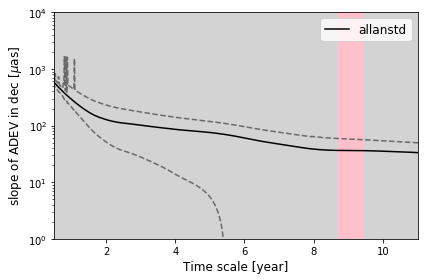

In [61]:
plt.figure()
# Calculate the slopes
slopes_dec = np.diff(np.log10(allanstd_dec_new)) / np.diff(np.log10(tau_dec_new))
# Plot allanstd
plt.plot(tau_dec_year,allanstd_dec_new,color='black',label='allanstd')
# Color background according to the slopes / noise type
plt.fill_between(tau_dec_year[1:], 1, 10**4, where= slopes_dec  < -0.25,color='lightgray',linewidth=1.0,zorder=1)
plt.fill_between(tau_dec_year[1:], 1, 10**4, where= (-0.25 <= slopes_dec ) & (slopes_dec  <= 0.25),color='pink',linewidth=1.0)
plt.fill_between(tau_dec_year[1:], 1, 10**4, where= slopes_dec  > 0.25,color='red',step='mid',linewidth=1.0)
# Plot confidence interval
plt.plot(tau_dec_year, allanstd_dec_new + bottom_dec,color='dimgrey',linestyle='dashed')
plt.plot(tau_dec_year, allanstd_dec_new + top_dec,color='dimgrey',linestyle='dashed')

plt.yscale('log')
plt.xlabel('Time scale [year]', fontsize=12)
plt.ylabel(r'slope of ADEV in dec [$\mu$as]', fontsize=12)
plt.legend(fontsize=12)
plt.ylim(1,10**4)
plt.xlim(0.5,11)
plt.tight_layout()

In [37]:
%%time
tau_ra_new, allanstd_ra_new, edfs_ra = allanoadev_new(df['RAcosDEC'].values,df['MJD'].values,df['Err. R.A. (micas)'].values)

0 908 2729 1160
0
1 908 2728 686
0
2 908 2727 499
0
3 908 2726 361
0
4 908 2725 266
0
5 908 2724 203
0
6 908 2723 159
0
7 908 2722 130
0
8 908 2721 112
0
9 908 2720 92
0
10 908 2719 78
0
11 908 2718 64
0
12 908 2717 52
0
13 908 2716 40
0
14 908 2715 31
0
15 908 2714 21
0
16 908 2713 14
0
17 908 2712 9
0
18 908 2711 4
0
19 908 2710 2
0
20 908 2709 1
0
21 908 2708 0
0
22 908 2707 0
0
23 908 2706 0
0
24 908 2705 0
0
25 908 2704 0
0
26 908 2703 0
0
27 908 2702 0
0
28 908 2701 0
1
29 908 2700 0
0
30 908 2699 0
0
31 908 2698 0
0
32 908 2697 0
0
33 908 2696 0
0
34 908 2695 0
0
35 908 2694 0
0
36 908 2693 0
0
37 908 2692 0
0
38 908 2691 0
0
39 908 2690 0
0
40 908 2689 0
0
41 908 2688 0
0
42 908 2687 0
0
43 908 2686 0
0
44 908 2685 0
0
45 908 2684 0
0
46 908 2683 0
0
47 908 2682 0
0
48 908 2681 0
0
49 908 2680 0
0
50 908 2679 0
0
51 908 2678 0
0
52 908 2677 0
0
53 908 2676 0
0
54 908 2675 0
0
55 908 2674 0
0
56 908 2673 0
-1
57 908 2672 0
0
58 908 2671 0
0
59 908 2670 0
0
60 908 2669 0
-1
61 90

In [62]:
tau_ra_year, bottom_ra, top_ra = process_allan(df['RAcosDEC'].values,tau_ra_new,edfs_ra)

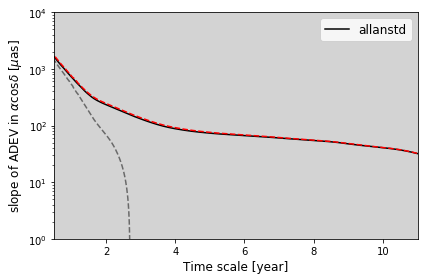

In [64]:
plt.figure()
# Calculate the slopes
slopes_ra = np.diff(np.log10(allanstd_ra_new)) / np.diff(np.log10(tau_ra_new))
# Plot allanstd
plt.plot(tau_ra_year,allanstd_ra_new,color='black',label='allanstd')
# Color background according to the slopes / noise type
plt.fill_between(tau_ra_year[1:], 1, 10**4, where= slopes_ra  < -0.25,color='lightgray',linewidth=1.0,zorder=1)
plt.fill_between(tau_ra_year[1:], 1, 10**4, where= (-0.25 <= slopes_ra ) & (slopes_ra  <= 0.25),color='pink',linewidth=1.0)
plt.fill_between(tau_ra_year[1:], 1, 10**4, where= slopes_ra  > 0.25,color='red',step='mid',linewidth=1.0)
# Plot confidence interval
plt.plot(tau_ra_year, allanstd_ra_new - bottom_ra,color='dimgrey',linestyle='dashed')
plt.plot(tau_ra_year, allanstd_ra_new + top_ra,color='red',linestyle='dashed')

plt.yscale('log')
plt.xlabel('Time scale [year]', fontsize=12)
plt.ylabel(r'slope of ADEV in $\alpha\cos{\delta}$ [$\mu$as]', fontsize=12)
plt.legend(fontsize=12)
plt.ylim(1,10**4)
plt.xlim(0.5,11)
plt.tight_layout()

# Debugging RA data

In [ ]:
# === Parameters ===
y = df['RAcosDEC'].values
t = df['MJD'].values
error = df['Err. R.A. (micas)'].values
# Length of observation
N = len(y)

# m array where 3 < m < N/3 
m = np.arange(3,1+round(N//3),1)
# initial sampling time
tau0 =  np.mean(np.diff(t))
# steps
step = tau0

# Empty variance array
allanvar = []
# Empty tau values array 
tau = []

edfs = []

# Iterate over values of m
for k in range(len(m)): 
    # Sliding windows 
    left = min(t)
    right = min(t) + m[k]*tau0

    # Array for averages
    ybar = []

    # Array for amount of data points
    Nrray = []

    # Define no of windows with <= 2 data points
    nconstraint = 2

    # Check for missing windows 
    while right <= max(t):
        data_values = y[(t>=left) & (t<=right)]
        Ndata = len(data_values)
        Nrray.append(Ndata)

        if Ndata == 0:
            ybar.append(np.nan)
        else:
            if error is None: 
                avg = np.average(data_values)
                ybar.append(avg)
            else:
                weights_std = 1/error[(t>=left) & (t<=right)]**2
                avg = np.average(data_values, weights=weights_std)
                ybar.append(avg)
        left += step 
        right += step    

    # Define empty windows 
    Nrray = np.array(Nrray)
    ybar = np.array(ybar)

    D = len(ybar[Nrray<=nconstraint])
    M = len(ybar)
#     print(k,len(m),M,D)

    # Discard windows with too few data points
    ybar = ybar[Nrray>nconstraint]

    # Calculate allan var 
    outersum = []
    j = 0
    while j < M-2*m[k]+1-D:
        i = j
        innersum = []
        while i <= j+m[k]-1:
            innersum.append(ybar[i+m[k]]-ybar[i])
            i += 1
        outersum.append(0.5*(np.sum(innersum)/m[k])**2)
        j += 1


    # Calculate allan variance
    allanvar.append(np.sum(outersum)/(M-2*m[k]+1-D))

    # Calculate tau
    tau.append(tau0*m[k])

    # Calc edf
    try:
        alpha_int = tpy.noise_id(y,m[k])[0]
    except:
        alpha_int = 0
    print(m[k], alpha_int)
    if (alpha_int<3) and (alpha_int>-3):
        edf = tpy.edf_greenhall(alpha_int,2,m[k],N,overlapping=True)
    else:
        edf = tpy.edf_approx(N,m[k])
    
    edfs.append(edf)

# Calculate allan std dev
allanstd = np.sqrt(allanvar)

In [ ]:
edfs

In [ ]:
tau_year = [x/365.242198781 for x in tau]

In [ ]:
plt.figure()
# Calculate the slopes
slopes_dec = np.diff(np.log10(allanstd)) / np.diff(np.log10(allanstd))
# Plot allanstd
plt.plot(tau_dec_year,allanstd_dec_new,color='black',label='allanstd')
# Color background according to the slopes / noise type
plt.fill_between(tau_year[1:], 1, 10**4, where= slopes_dec  < -0.25,color='lightgray',linewidth=1.0,zorder=1)
plt.fill_between(tau_year[1:], 1, 10**4, where= (-0.25 <= slopes_dec ) & (slopes_dec  <= 0.25),color='pink',linewidth=1.0)
plt.fill_between(tau_year[1:], 1, 10**4, where= slopes_dec  > 0.25,color='red',step='mid',linewidth=1.0)
# Plot confidence interval
plt.plot(tau_dec_year, allanstd_dec_new + bottom,color='dimgrey',linestyle='dashed')
plt.plot(tau_dec_year, allanstd_dec_new + top,color='dimgrey',linestyle='dashed')

plt.yscale('log')
plt.xlabel('Time scale [year]', fontsize=fs)
plt.ylabel(r'slope of ADEV in RAcosdec [$\mu$as]', fontsize=fs)
plt.legend(fontsize=12)
plt.ylim(1,10**4)
plt.xlim(0.5,11)
plt.tight_layout()

In [ ]:
if np.isnan(test) == True:
    test = 0
    print(test)

# Using own func

In [ ]:
tpy.noise_id(y,3)

In [ ]:
def noise_id(y):
    dmin = 0 #default
    d = 0
    N = len(y)
    while True: 
        ybar = np.average(y)
        rnum = sum((y[i]-ybar)*(y[i+1]-ybar) for i in range (1,N-2))
        rdenom = sum((y[i]-ybar)**2 for i in range (1,N))
        r = rnum/rdenom
        delta = r/(1+r)
        if d>=dmin and delta < 0.25:
            alpha = -2*(delta+d)
            break
        else:
            y[1] = y[N] - y[N-1]
            N -= 1
            d += 1
    return alpha

In [ ]:
y = df['Dec. (micas)'].values

In [ ]:
noise_id(y)

In [ ]:
y

In [ ]:
dmin = 0 #default
d = 0
N = len(y)

In [ ]:
N

In [ ]:
ybar = np.average(y)
rnumsum = []
i = 0
while i <= N-2:
    prod = (y[i]-ybar)*(y[i+1]-ybar)
    rnumsum.append(prod)
    i+=1

In [ ]:
    rdenom = sum((y[i]-ybar)**2 for i in range (1,N+1))
    r = rnum/rdenom
    delta = r/(1+r)
    if d>=dmin and delta < 0.25:
        alpha = -2(delta+d)
        break
    else:
        y[1] = y[N] - y[N-1]
        N -= 1
        d += 1